In [271]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import os

import importlib
import utils
from logger import ExperimentLogger

importlib.reload(utils)
argFile = 'parameters.json'
try:
    del args
except NameError:
    pass
args = utils.loadJson(argFile)
if args.LoRA:
    args.method = "LoRA"
elif args.wt:
    args.method = "LoRA_full_rank"
else :
    args.method = "standard"

In [272]:
def load_runs_with_constraints(path, args):
    runs = ExperimentLogger.load_group(path)

    def match(meta):
        return (
            meta["L"] == args.L and
            meta["beta"] == args.beta and
            meta["method"] == args.method and
            np.isclose(meta["rho"], args.rho) and
            meta["M"] == args.M and
            meta["K"] == args.K and
            meta["N"] == args.N and
            meta["A_only"] == args.A_only
        )

    filtered = [r for r in runs if match(r["metadata"])]

    if len(filtered) == 0:
        print("file is empty !")

    return filtered

def runs_to_dict(runs):
    logs = runs[0]["logs"]

    out = {"metadata": runs[0]["metadata"]}

    # global steps if consistent, otherwise keep per-key
    out["steps"] = {}

    for key, entry in logs.items():
        out["steps"][key] = np.array(entry["steps"])

        values = entry["values"]

        if len(values) == 0:
            continue

        out[key] = np.array(values, dtype=object)

    return out
    
# Load the simulation
path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
training_runs = load_runs_with_constraints(path_to_sim, args)

path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
ode_runs = load_runs_with_constraints(path_to_sim_ODEs, args)

df = runs_to_dict(training_runs)
df_ODES = runs_to_dict(ode_runs)


/tmp/ipykernel_686191/4284805552.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


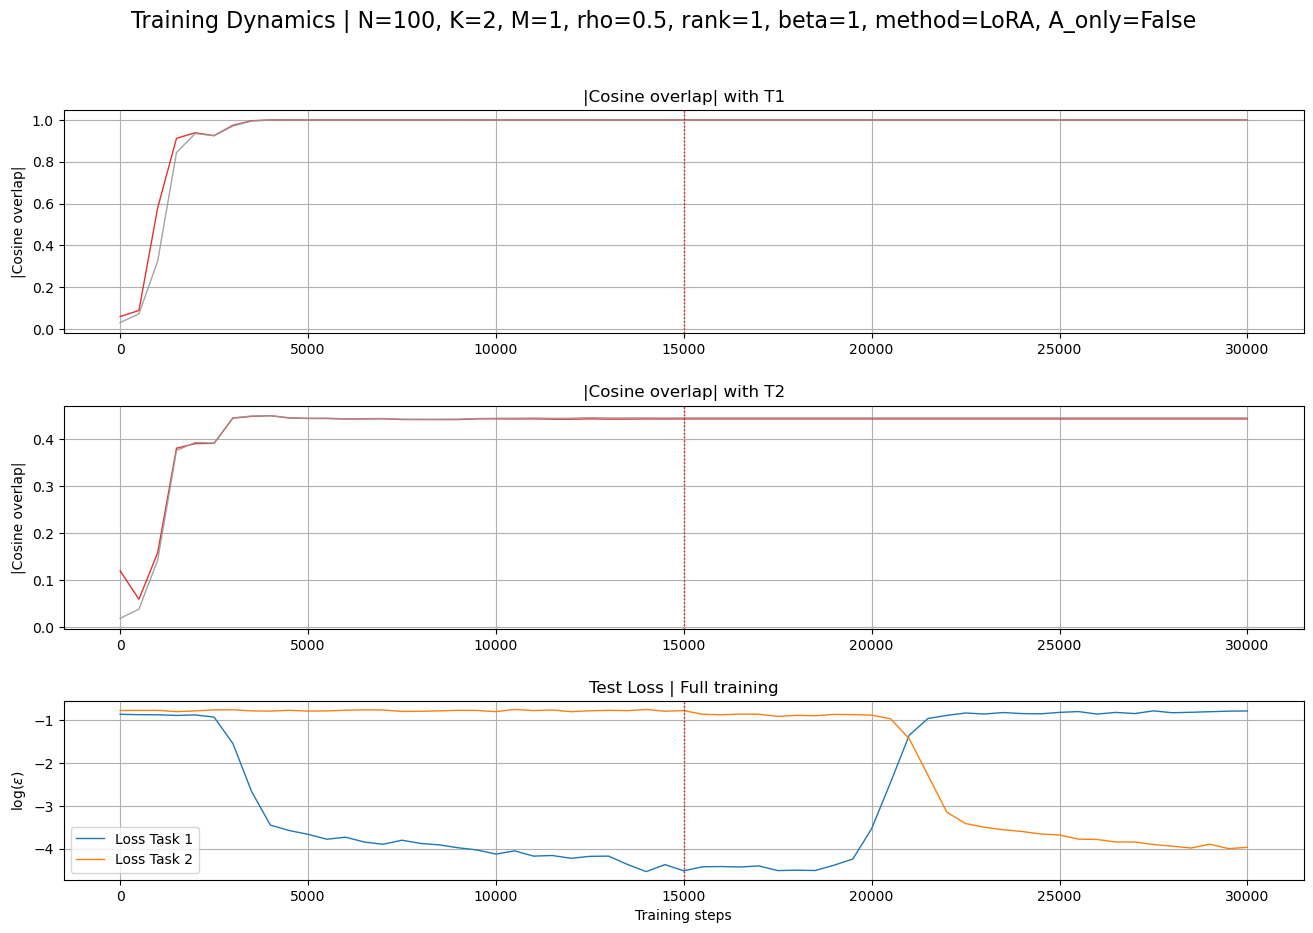

In [273]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

colors = cm.Set1(np.linspace(0, 1, args.K * args.M))

# ---------------- CONSTANT ----------------
P = df["metadata"]["alpha"] * df["metadata"]["N"]

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Training Dynamics | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only}",
    fontsize=16
)

gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.8], hspace=0.35)

# =========================================================
# TOP: T1 overlaps (matrix-valued signal)
# =========================================================
ax_t1 = fig.add_subplot(gs[0, 0])

t1_series = np.array(df["overlap_t1"], dtype=object)
t1_steps = np.array(df["steps"]["overlap_t1"])

for idx, (i, j) in enumerate([(i, j) for i in range(args.K) for j in range(args.M)]):

    values = np.array([mat[i, j] for mat in t1_series])

    ax_t1.plot(
        t1_steps,
        np.abs(values),
        lw=1,
        color=colors[idx],
        alpha=0.9
    )

ax_t1.set_title("|Cosine overlap| with T1")
ax_t1.set_ylabel("|Cosine overlap|")
ax_t1.axvline(x=P, linestyle=":", color="red", lw=1)
ax_t1.grid(True)


# =========================================================
# MIDDLE: T2 overlaps (scalar/vector signals per pair)
# =========================================================
ax_t2 = fig.add_subplot(gs[1, 0])

t2_series = np.array(df["overlap_t2"], dtype=object)
t2_steps = np.array(df["steps"]["overlap_t2"])
for idx, (i, j) in enumerate([(i, j) for i in range(args.K) for j in range(args.M)]):

    values = np.array([mat[i, j] for mat in t2_series])

    ax_t2.plot(
        t1_steps,   # or df["steps"]["overlap_t1"] if shared
        np.abs(values),
        lw=1,
        color=colors[idx],
        alpha=0.9
    )


ax_t2.set_title("|Cosine overlap| with T2")
ax_t2.set_ylabel("|Cosine overlap|")
ax_t2.axvline(x=P, linestyle=":", color="red", lw=1)
ax_t2.grid(True)


# =========================================================
# BOTTOM: LOSS CURVES
# =========================================================
ax_loss = fig.add_subplot(gs[2, 0])
loss1 = np.asarray(df["test_loss_1"], dtype=np.float64)
loss2 = np.asarray(df["test_loss_2"], dtype=np.float64)
steps_loss = np.array(df["steps"]["test_loss_1"])

ax_loss.plot(
    steps_loss,
    np.log10(loss1),
    lw=1,
    label="Loss Task 1"
)

ax_loss.plot(
    steps_loss,
    np.log10(loss2),
    lw=1,
    label="Loss Task 2"
)

ax_loss.set_title("Test Loss | Full training")
ax_loss.set_xlabel("Training steps")
ax_loss.set_ylabel(r"$\log(\epsilon)$")
ax_loss.axvline(x=P, linestyle=":", color="red", lw=1)
ax_loss.grid(True)
ax_loss.legend()


# =========================================================
# SAVE + SHOW
# =========================================================
plt.tight_layout()

plt.savefig(
    f"training_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_beta_{args.beta}_"
    f"{args.method}_A_only_{args.A_only}.pdf"
)

plt.show()

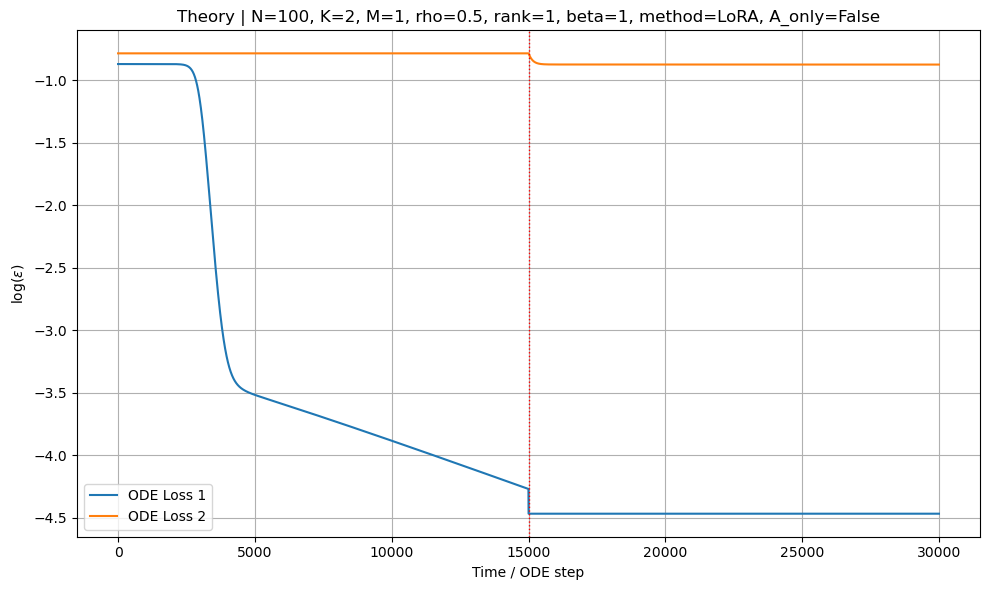

In [274]:
loss1 = np.asarray(df_ODES["test_loss_1"], dtype=np.float64)
loss2 = np.asarray(df_ODES["test_loss_2"], dtype=np.float64)

t_span = np.arange(len(loss1)) * args.integration_step * args.N

plt.figure(figsize=(10, 6))

plt.plot(t_span, np.log10(loss1), label="ODE Loss 1")
plt.plot(t_span, np.log10(loss2), label="ODE Loss 2")

plt.axvline(x=P, linestyle=":", color="red", lw=1.0)

plt.title(
    f"Theory | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only}"
)

plt.xlabel("Time / ODE step")
plt.ylabel(r"$\log(\epsilon)$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

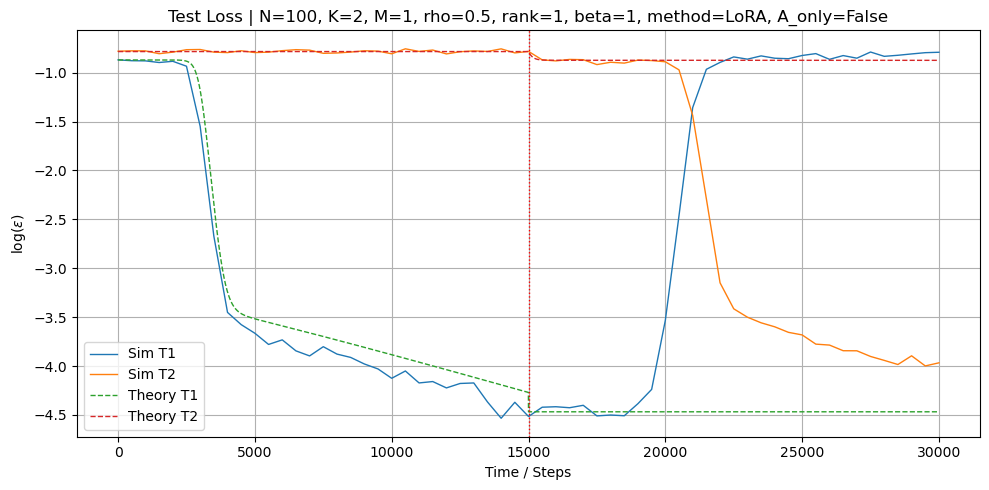

In [275]:
steps_loss = np.array(df["steps"]["test_loss_1"])
t_span = np.arange(len(loss1)) * args.integration_step * args.N

fig, ax = plt.subplots(figsize=(10, 5))

# =========================
# Simulation
# =========================
ax.plot(
    steps_loss,
    np.log10(np.asarray(df["test_loss_1"], dtype=np.float64)),
    label="Sim T1",
    lw=1
)

ax.plot(
    steps_loss,
    np.log10(np.asarray(df["test_loss_2"], dtype=np.float64)),
    label="Sim T2",
    lw=1
)

# =========================
# Theory (ODE) — FIX HERE
# =========================

ax.plot(
    t_span,
    np.log10(np.asarray(df_ODES["test_loss_1"], dtype=np.float64)),
    "--",
    label="Theory T1",
    lw=1
)

ax.plot(
    t_span,
    np.log10(np.asarray(df_ODES["test_loss_2"], dtype=np.float64)),
    "--",
    label="Theory T2",
    lw=1
)

# =========================
# Task boundary (IMPORTANT FIX)
# =========================
P_time = args.N * args.alpha   # ensure same unit as simulation steps

ax.axvline(x=P_time, linestyle=":", color="red", lw=1)

# =========================
ax.set_title(
    f"Test Loss | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only}"
)
ax.set_xlabel("Time / Steps")
ax.set_ylabel(r"$\log(\epsilon)$")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(
    f"th_sim_N_{args.N}_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_beta_{args.beta}_"
    f"{args.method}_A_only_{args.A_only}.pdf"
)
plt.show()

In [269]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


def plot_overlaps(
    df,
    df_ODES,
    overlap,
    args,
    task=None,
    absval=True,
):

    # =========================================================
    # LOAD DATA
    # =========================================================
    sim_steps = np.array(df["steps"][overlap])
    ode_steps = np.array(df_ODES["steps"][overlap])
    ode_steps = ode_steps * args.integration_step * args.N


    sim_values = np.asarray(df[overlap], dtype=object)
    ode_values = np.asarray(df_ODES[overlap], dtype=object)

    # =========================================================
    # PHASE SELECTION
    # =========================================================
    P = args.alpha * args.N

    if task == 1:

        sim_mask = sim_steps <= P
        ode_mask = ode_steps <= P

    elif task == 2:

        sim_mask = sim_steps >= P
        ode_mask = ode_steps >= P

    else:

        sim_mask = np.ones_like(sim_steps, dtype=bool)
        ode_mask = np.ones_like(ode_steps, dtype=bool)

    first = sim_values[0]

    # =========================================================
    # SCALAR CASE
    # =========================================================
    if np.isscalar(first):

        plt.figure(figsize=(9, 5))

        vals_sim = np.asarray(sim_values, dtype=np.float64)
        vals_ode = np.asarray(ode_values, dtype=np.float64)

        if absval:
            vals_sim = np.abs(vals_sim)
            vals_ode = np.abs(vals_ode)

        plt.plot(
            sim_steps[sim_mask],
            vals_sim[sim_mask],
            lw=1.5,
            label="Simulation",
        )

        plt.plot(
            ode_steps[ode_mask],
            vals_ode[ode_mask],
            "--",
            lw=1.5,
            label="Theory",
        )

    else:

        shape = np.array(first).shape

        # =====================================================
        # VECTOR CASE
        # =====================================================
        if len(shape) == 1:

            dim = shape[0]

            colors = cm.Set1(np.linspace(0, 1, dim))

            plt.figure(figsize=(10, 6))

            for i in range(dim):

                vals_sim = np.array(
                    [vec[i] for vec in sim_values],
                    dtype=np.float64,
                )

                vals_ode = np.array(
                    [vec[i] for vec in ode_values],
                    dtype=np.float64,
                )

                if absval:
                    vals_sim = np.abs(vals_sim)
                    vals_ode = np.abs(vals_ode)

                plt.plot(
                    sim_steps[sim_mask],
                    vals_sim[sim_mask],
                    color=colors[i],
                    lw=1,
                    alpha=0.9,
                    label=f"Sim ({i})"
                )

                plt.plot(
                    ode_steps[ode_mask],
                    vals_ode[ode_mask],
                    "--",
                    color=colors[i],
                    lw=1,
                    alpha=0.9,
                    label=f"ODE ({i})"
                )

        # =====================================================
        # MATRIX CASE
        # =====================================================
        elif len(shape) == 2:

            K, M = shape

            colors = cm.Set1(np.linspace(0, 1, K * M))

            plt.figure(figsize=(10, 6))

            for idx, (i, j) in enumerate(
                [(i, j) for i in range(K) for j in range(M)]
            ):

                vals_sim = np.array(
                    [mat[i, j] for mat in sim_values],
                    dtype=np.float64,
                )

                vals_ode = np.array(
                    [mat[i, j] for mat in ode_values],
                    dtype=np.float64,
                )

                if absval:
                    vals_sim = np.abs(vals_sim)
                    vals_ode = np.abs(vals_ode)

                plt.plot(
                    sim_steps[sim_mask],
                    vals_sim[sim_mask],
                    color=colors[idx],
                    lw=1,
                    alpha=0.9,
                    label=f"Sim ({i},{j})"
                )

                plt.plot(
                    ode_steps[ode_mask],
                    vals_ode[ode_mask],
                    "--",
                    color=colors[idx],
                    lw=1,
                    alpha=0.9,
                    label=f"ODE ({i},{j})"
                )

        else:

            raise ValueError(
                f"{overlap} has unsupported shape {shape}"
            )

    # =========================================================
    # FINAL FORMATTING
    # =========================================================
    plt.axvline(
        x=P,
        linestyle=":",
        color="red",
        lw=1,
    )

    plt.title(
        f"{overlap} | "
        f"N={args.N}, K={args.K}, M={args.M}, "
        f"rho={args.rho}, rank={args.L}, "
        f"beta={args.beta}, method={args.method}, "
        f"A_only={args.A_only}"
    )

    plt.xlabel("Training steps")
    plt.ylabel(overlap)

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

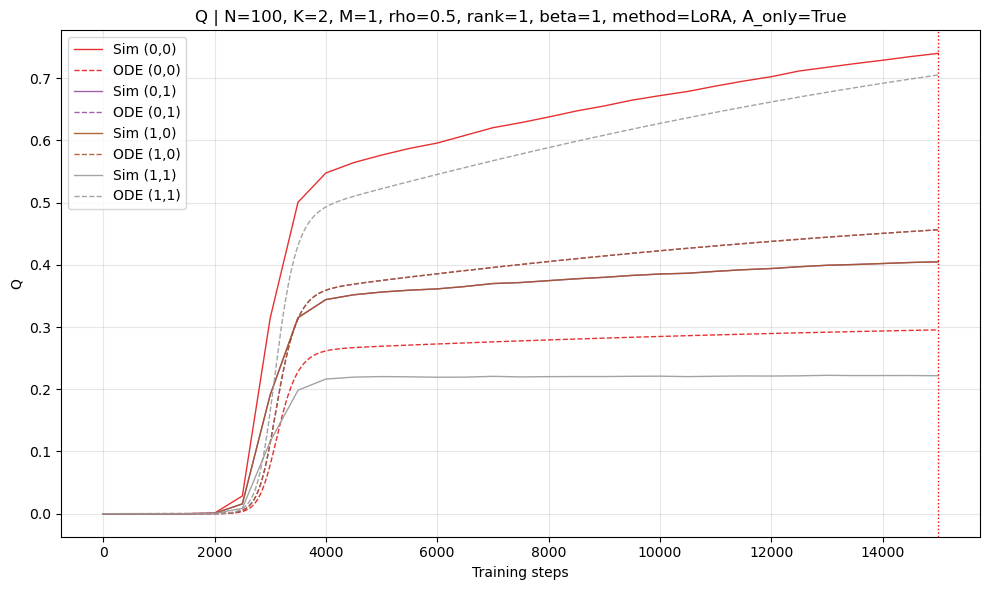

In [270]:
plot_overlaps(
    df,
    df_ODES,
    "Q",
    args,
    task=None,
    absval=True,
)

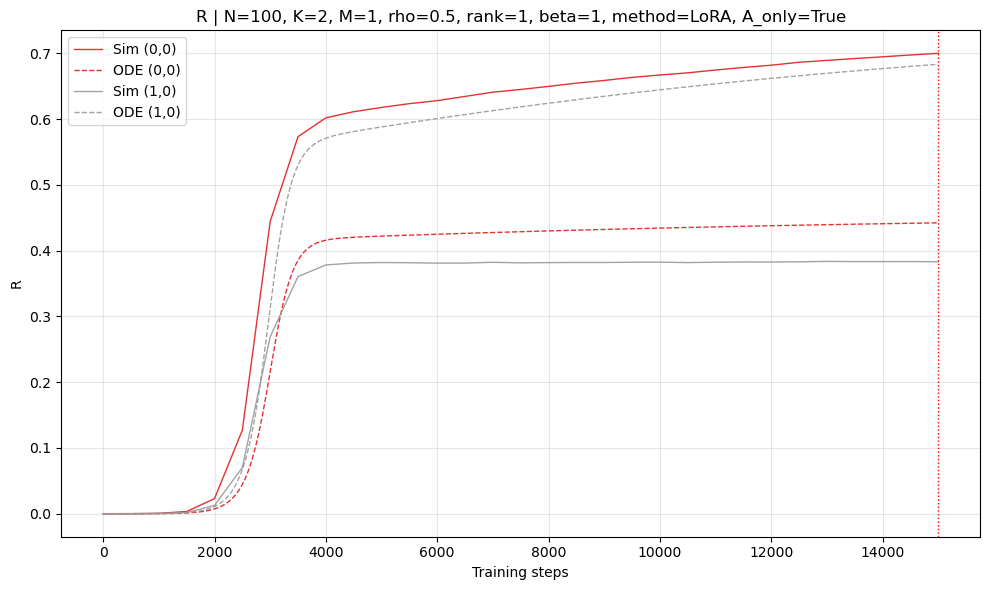

In [259]:
plot_overlaps(
    df,
    df_ODES,
    "R",
    args,
    task=None,
    absval=True,
)

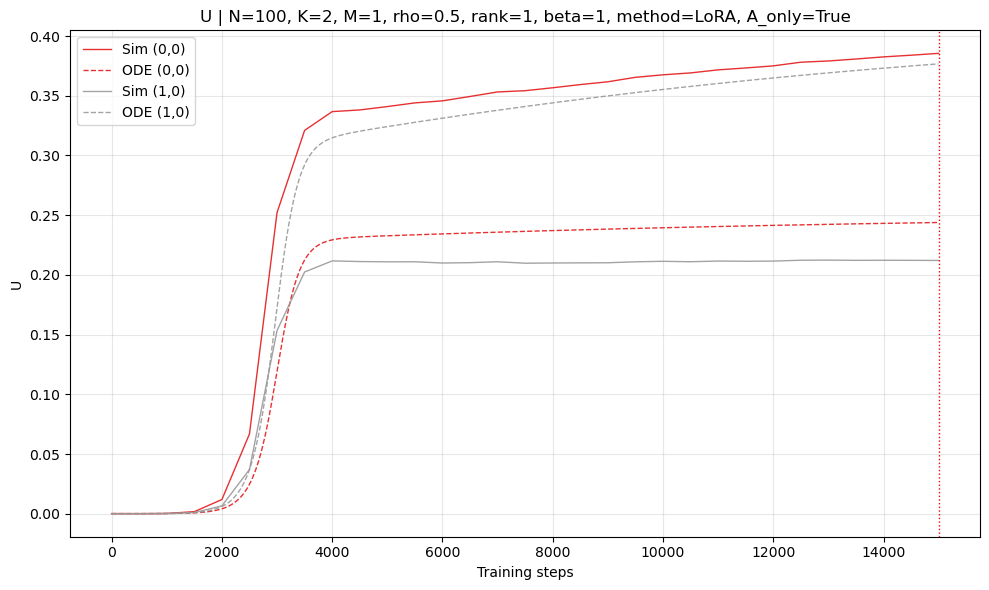

In [260]:
plot_overlaps(
    df,
    df_ODES,
    "U",
    args,
    task=None,
    absval=True,
)

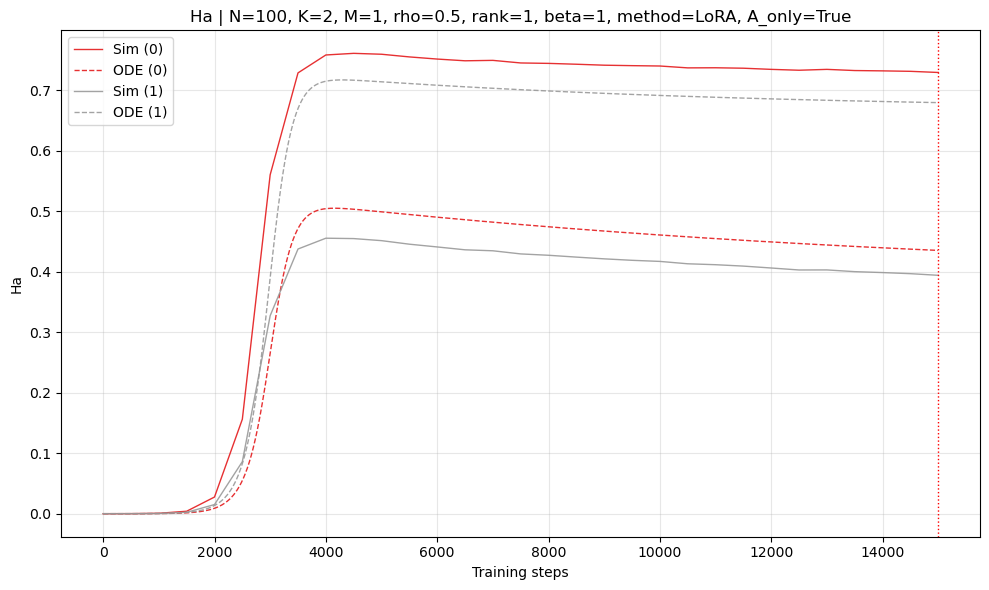

In [261]:
plot_overlaps(
    df,
    df_ODES,
    "Ha",
    args,
    task=None,
    absval=True,
)

In [262]:
plot_overlaps(
    df,
    df_ODES,
    "D",
    args,
    task=2,
    absval=True,
)

KeyError: 'D'

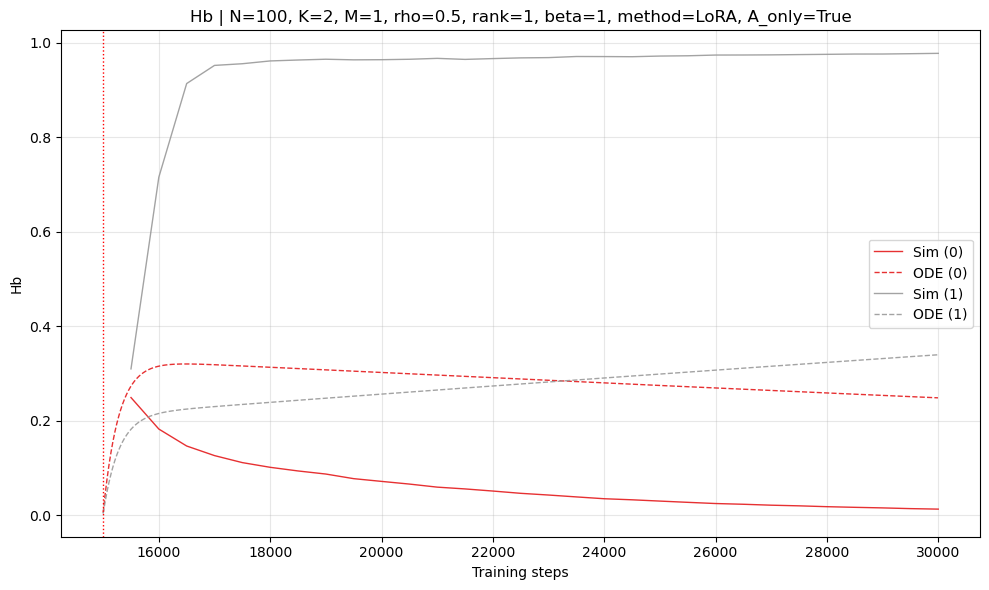

In [263]:
plot_overlaps(
    df,
    df_ODES,
    "Hb",
    args,
    task=2,
    absval=True,
)

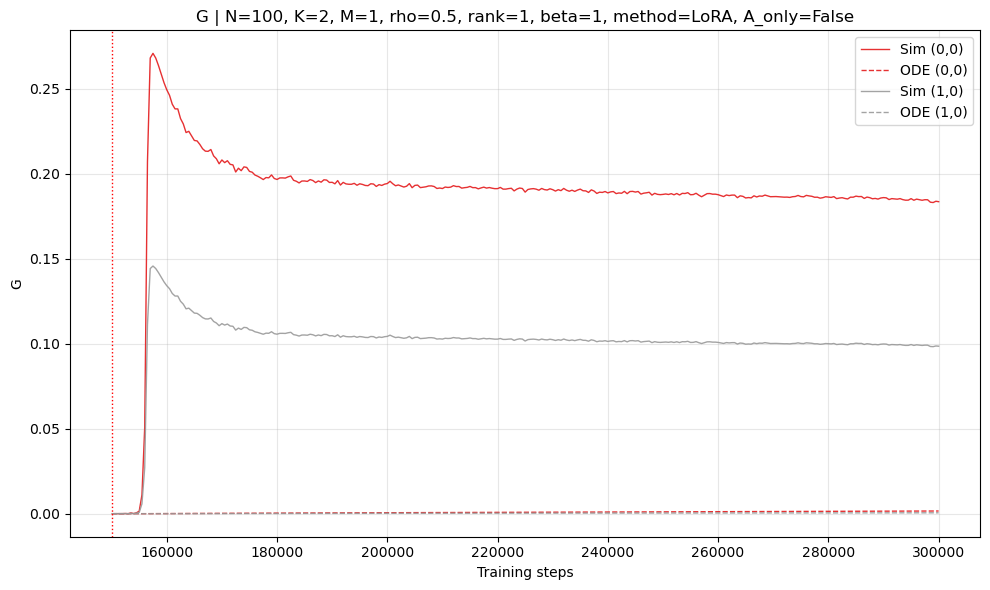

In [247]:
plot_overlaps(
    df,
    df_ODES,
    "G",
    args,
    task=2,
    absval=True,
)

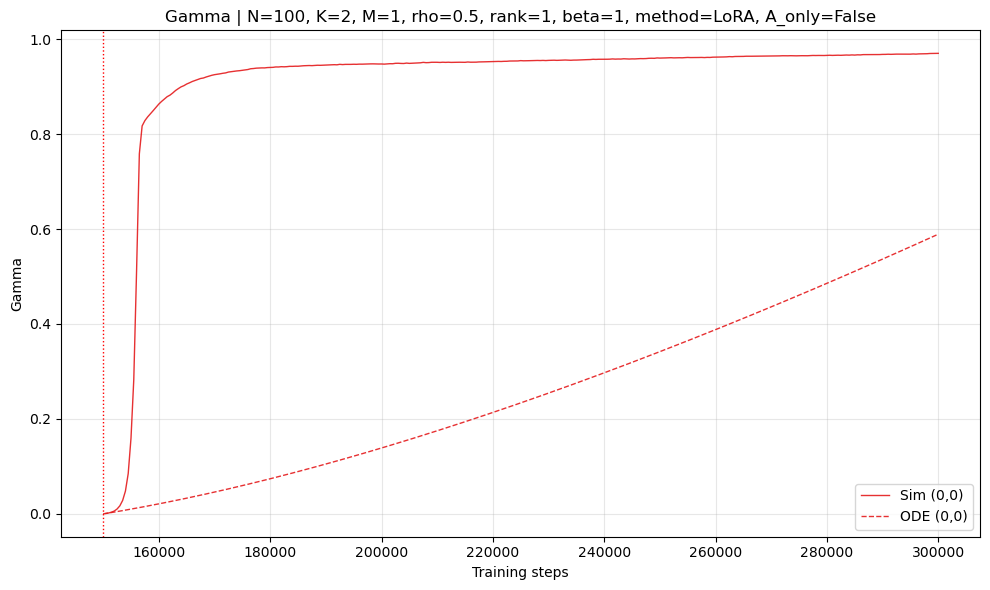

In [248]:
plot_overlaps(
    df,
    df_ODES,
    "Gamma",
    args,
    task=2,
    absval=True,
)

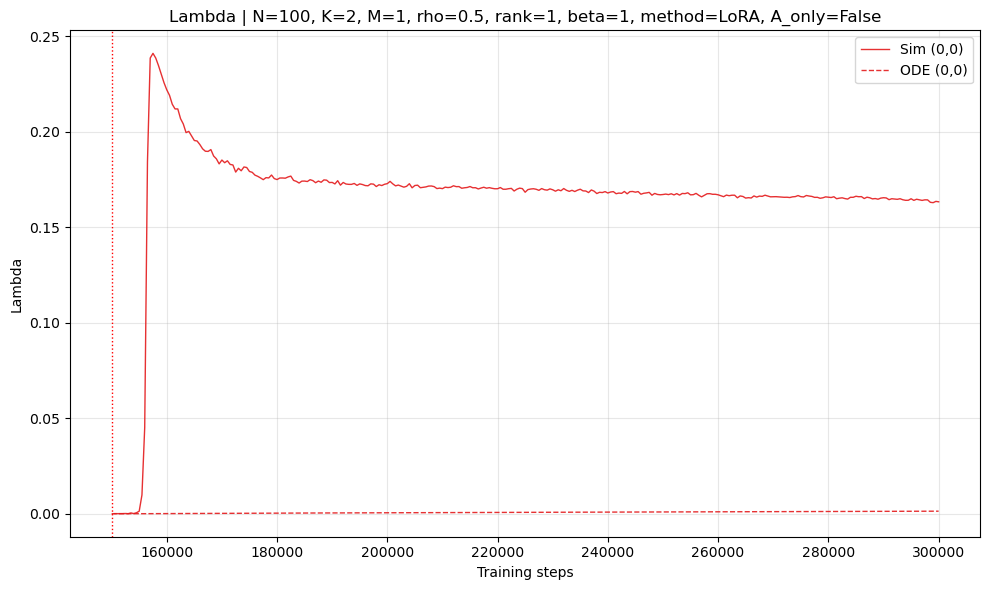

In [249]:
plot_overlaps(
    df,
    df_ODES,
    "Lambda",
    args,
    task=2,
    absval=True,
)

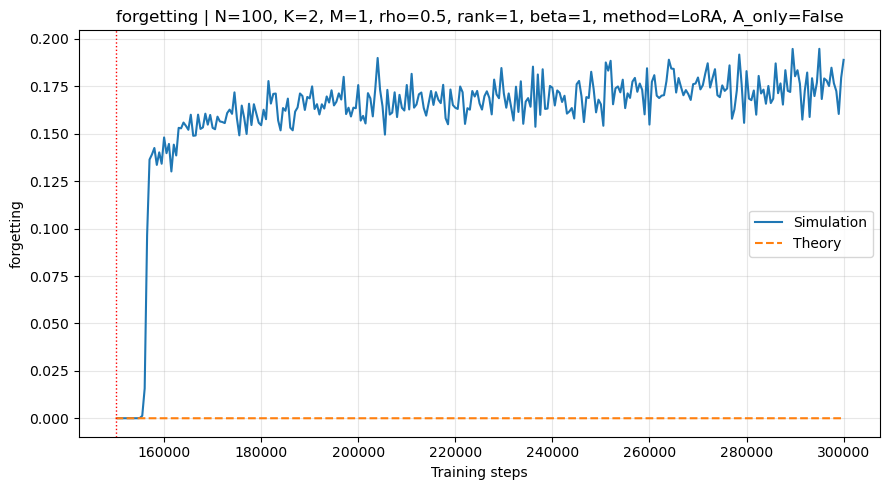

In [250]:
plot_overlaps(
    df,
    df_ODES,
    "forgetting",
    args,
    task=2,
    absval=True,
)

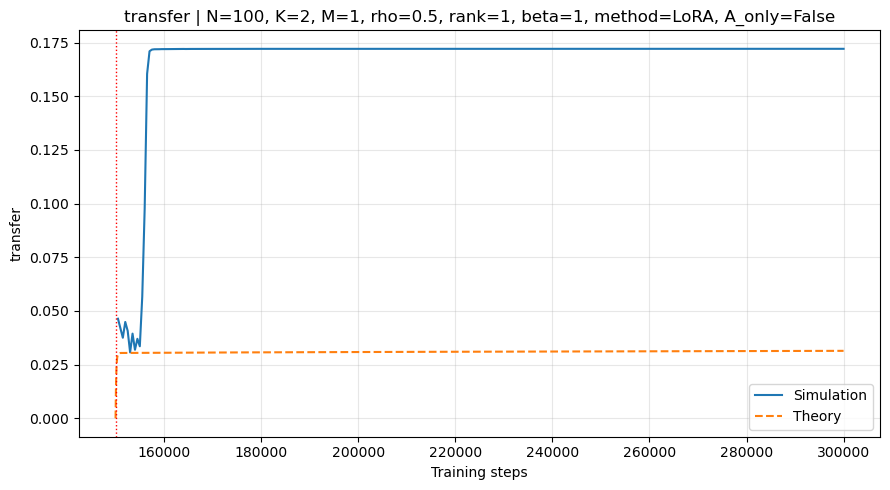

In [251]:
plot_overlaps(
    df,
    df_ODES,
    "transfer",
    args,
    task=2,
    absval=True,
)

# TODO
1) Plot LGS 
2) Plot LGS + LoRA + Th LoRA 
3) Plot LGS + LoRA + A_only + Th LoRA + Th A_only 
4) Transfer + forgetting in 3 settings.


# 1) Plot LGS

In [208]:
def plot_curves(ax, df, label_suffix="", color=None, ODES= False, lw=1):
    if ODES == False :
        x_axis = df["steps"]
        alpha = 1.0
        lw=1.5
        marker = None
        markevery= None
    else :
        x_axis = args.N * np.arange(0,2*args.alpha,args.integration_step)
        lw = 2.5
        alpha = 0.8
        marker = "o"
        markevery = 50
    
    ax.plot(
        x_axis,
        np.log10(df["test_loss1"]),
        linewidth=lw,
        linestyle="-",
        marker=marker,
        markevery=markevery,
        markersize=4,
        color=color,
        alpha=alpha,
        label=f"Task 1 {label_suffix}",
    )

    ax.plot(
        x_axis,
        np.log10(df["test_loss2"]),
        linewidth=lw,
        linestyle=":",
        marker=marker,
        markevery=markevery,
        markersize=4,
        color=color,
        alpha=alpha,
        label=f"Task 2 {label_suffix}",
    )

args.rho=0

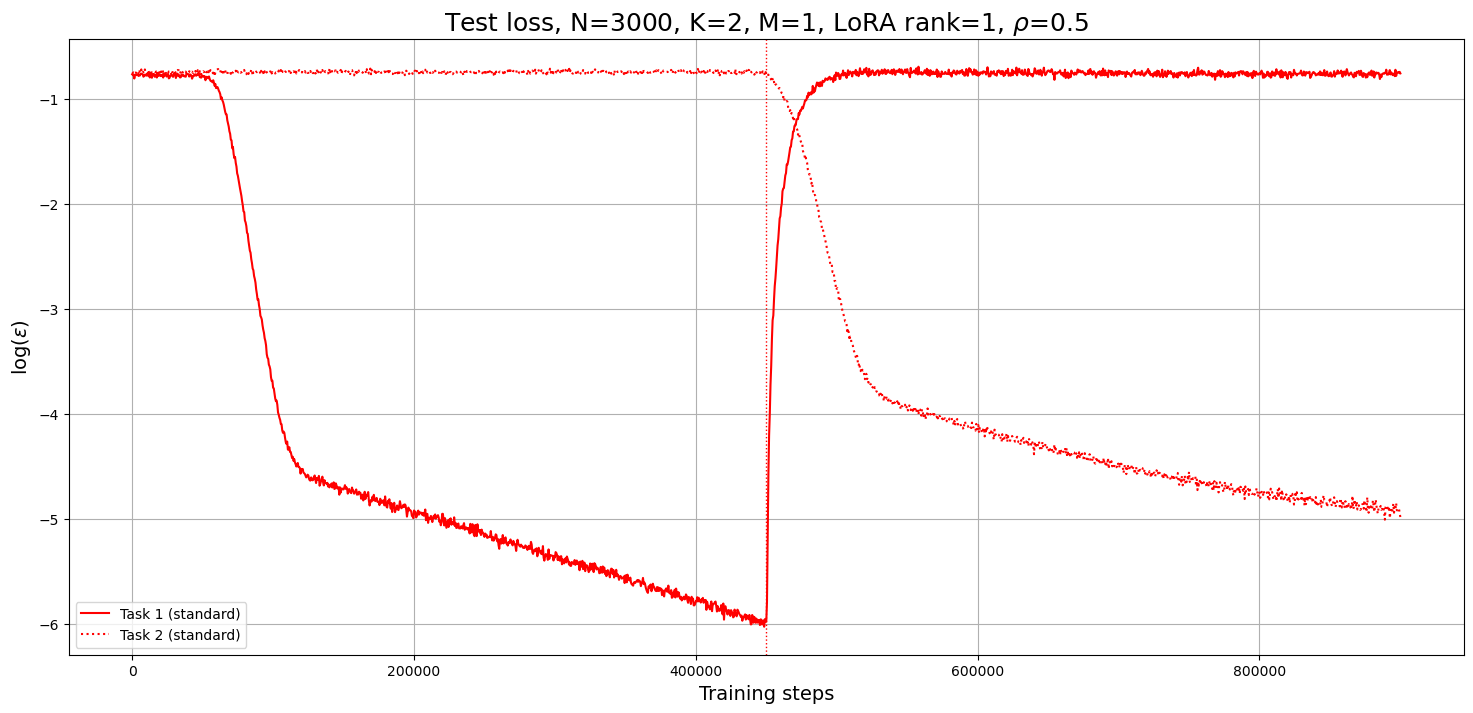

In [243]:
args.method="standard"
args.A_only = False
path_to_sim = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}.csv")
df = load_df_with_constraints(path_to_sim, args)

path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}_ODES.csv")
#df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

fig, ax = plt.subplots(figsize=(18, 8))

# First dataset
plot_curves(ax, df, label_suffix="(standard)", color=colors["standard"])
#plot_curves(ax,df_ODES,label_suffix="(ODEs)", ODES=True)

ax.set_title( rf"Test loss, N={args.N}, K={args.K}, M={args.M}, LoRA rank={args.L}, $\rho$={args.rho}", fontsize=18)
ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log(\epsilon)$", fontsize=14)
ax.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")

fig.savefig(os.path.join(args.path_to_res_folder, "1-test_loss_LGS.pdf"), format="pdf", bbox_inches="tight")

plt.show()

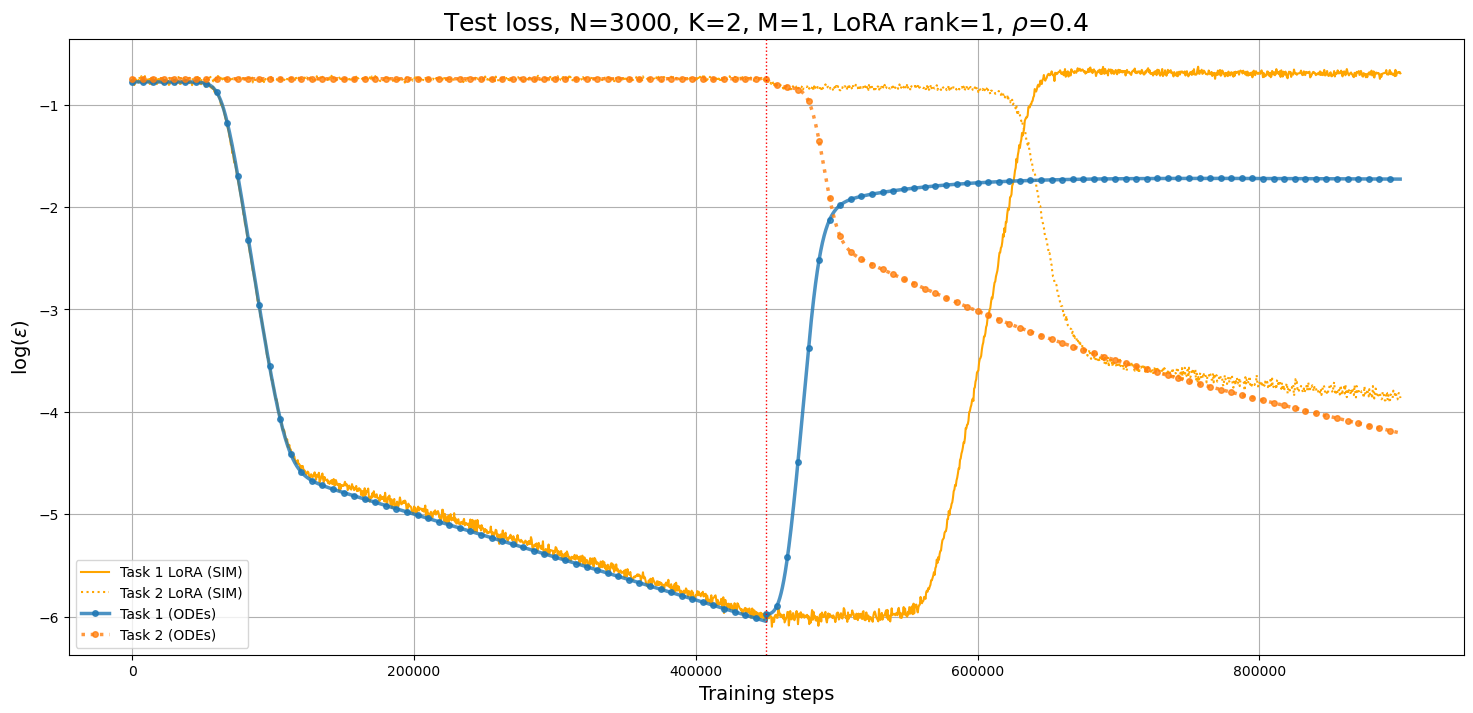

In [251]:
args.rho = 0.4

args.method="LoRA"
args.A_only = False
path_to_sim = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}.csv")
df = load_df_with_constraints(path_to_sim, args)

path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}_ODES.csv")
df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

fig, ax = plt.subplots(figsize=(18, 8))

# First dataset
plot_curves(ax, df, label_suffix="LoRA (SIM)", color=colors["LoRA"])

# Second dataset
plot_curves(ax,df_ODES,label_suffix="(ODEs)", ODES= True)

ax.set_title( rf"Test loss, N={args.N}, K={args.K}, M={args.M}, LoRA rank={args.L}, $\rho$={args.rho}", fontsize=18)
ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log(\epsilon)$", fontsize=14)
ax.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")
fig.savefig(os.path.join(args.path_to_res_folder, "2-test_loss_LoRA.pdf"), format="pdf", bbox_inches="tight")
plt.show()

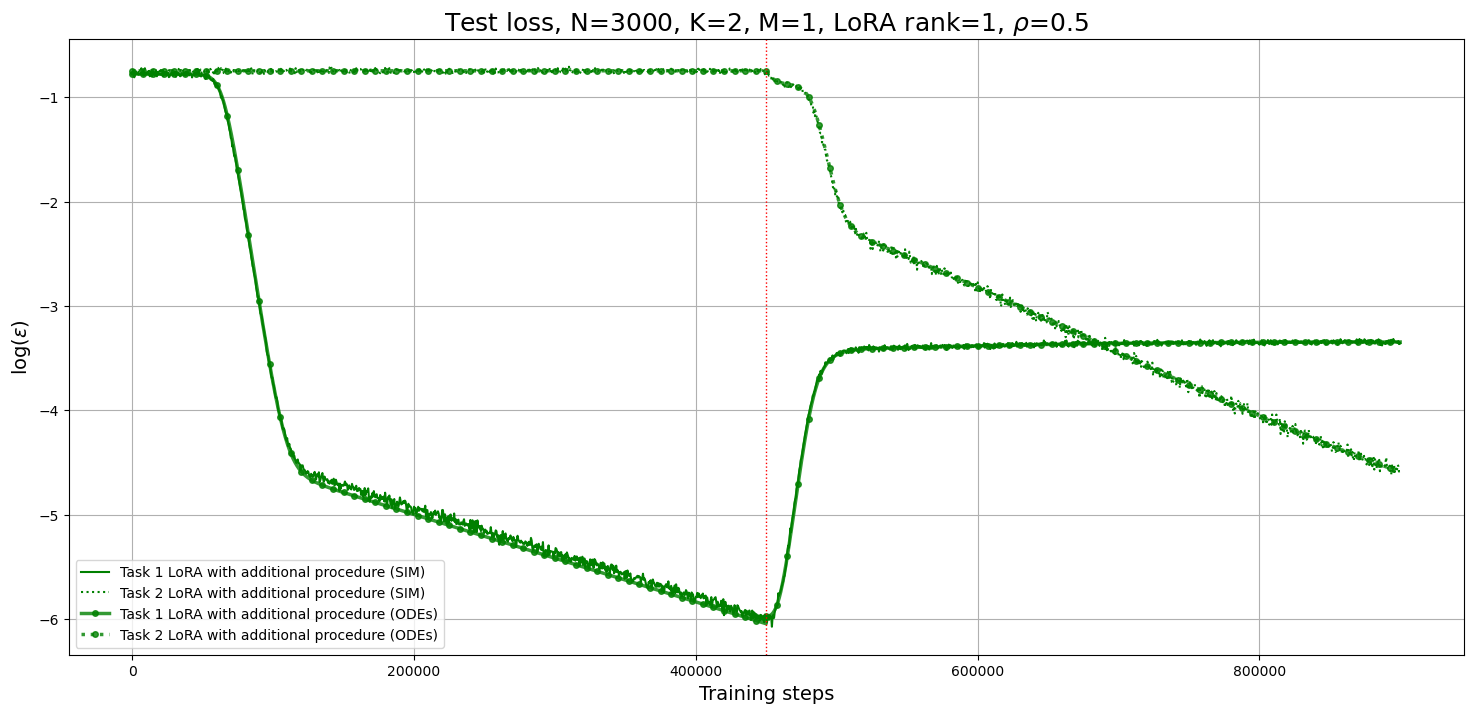

In [245]:
args.method="LoRA"
args.A_only = True
path_to_sim = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}.csv")
df = load_df_with_constraints(path_to_sim, args)

path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}_ODES.csv")
df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

fig, ax = plt.subplots(figsize=(18, 8))

# First dataset
plot_curves(ax, df, label_suffix="LoRA with additional procedure (SIM)", color=colors["LoRA_A_only"])

# Second dataset
plot_curves(ax,df_ODES,label_suffix="LoRA with additional procedure (ODEs)", color=colors["LoRA_A_only"], ODES= True)

ax.set_title( rf"Test loss, N={args.N}, K={args.K}, M={args.M}, LoRA rank={args.L}, $\rho$={args.rho}", fontsize=18)
ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log(\epsilon)$", fontsize=14)
ax.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")
fig.savefig(os.path.join(args.path_to_res_folder, "3-test_loss_LoRA_additional_procedure.pdf"), format="pdf", bbox_inches="tight")
plt.show()

file is empty !


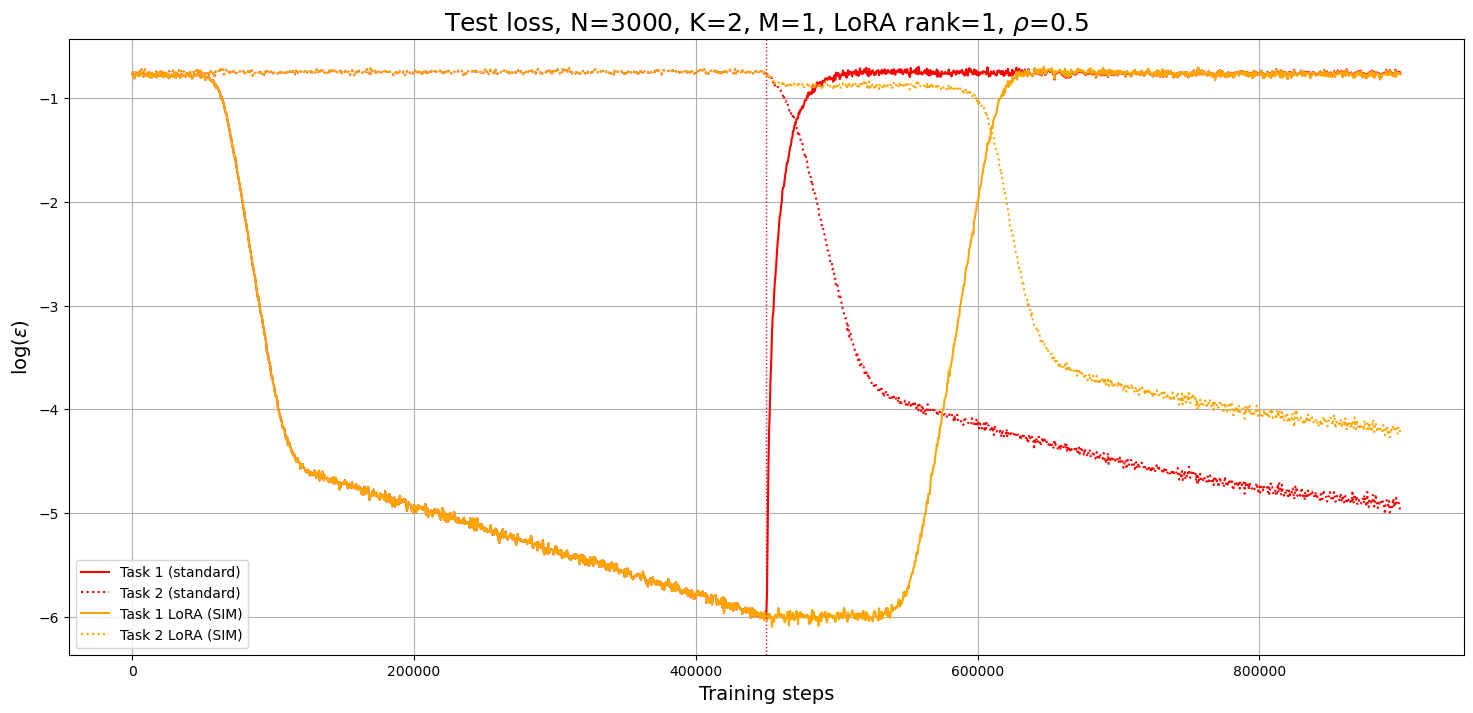

In [254]:
args.rho = 0.5
path_to_sim = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}.csv")
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}_ODES.csv")
fig, ax = plt.subplots(figsize=(18, 8))
colors = {
    "standard": "red",
    "LoRA": "orange",
    "LoRA_A_only": "green",
}

args.method="standard"
args.A_only = False
df = load_df_with_constraints(path_to_sim, args)
df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)
plot_curves(ax, df, label_suffix="(standard)", color=colors["standard"])
#plot_curves(ax,df_ODES,label_suffix="(standard)", ODES= True, linestyle="--")

args.method="LoRA"
args.A_only = False
df = load_df_with_constraints(path_to_sim, args)
df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)
plot_curves(ax, df, label_suffix="LoRA (SIM)", color=colors["LoRA"])
#plot_curves(ax,df_ODES,label_suffix="LoRA (ODEs)", color=colors["LoRA"],ODES= True, )

#args.method="LoRA"
#args.A_only = True
#df = load_df_with_constraints(path_to_sim, args)
#df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)
#plot_curves(ax, df, label_suffix="LoRA with additional procedure (SIM)", color=colors["LoRA_A_only"])
#plot_curves(ax,df_ODES,label_suffix="LoRA with additional procedure (ODEs)", color= colors["LoRA_A_only"], ODES= True, )




ax.set_title( rf"Test loss, N={args.N}, K={args.K}, M={args.M}, LoRA rank={args.L}, $\rho$={args.rho}", fontsize=18)
ax.set_xlabel("Training steps", fontsize=14)
ax.set_ylabel(r"$\log(\epsilon)$", fontsize=14)
ax.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax.grid(True)
ax.legend(loc="lower left")
fig.savefig(os.path.join(args.path_to_res_folder, "3bis-test_loss_LGS+LoRA.pdf"), format="pdf", bbox_inches="tight")
plt.show()

In [183]:
def plot_metric_vs_rho(
    ax,
    rhos,
    sim_values,
    ode_values=None,
    metric_name="Forgetting",
    label="",
    color=None
):
    """
    Plot a metric against rho for simulations and ODEs.
    """

    ax.plot(
        rhos,
        np.log10(sim_values),
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=color,
        label=f"{label} (SIM)",
    )

    if ode_values is not None:
        ax.plot(
            rhos,
            np.log10(ode_values),
            marker="s",
            markersize=7,
            linewidth=2.5,
            linestyle="--",
            color=color,
            label=f"{label} (ODEs)",
        )

    ax.set_xlabel(r"$\rho$", fontsize=14)
    ax.set_ylabel(
        rf"$\log_{{10}}(\mathrm{{{metric_name.lower()}}})$",
        fontsize=14,
    )

    ax.set_title(
        f"{metric_name} vs correlation parameter",
        fontsize=16,
    )

    ax.grid(True, alpha=0.3)

    ax.legend(frameon=True, fontsize=12)

    ax.set_xticks(rhos)

    ax.margins(x=0.02)

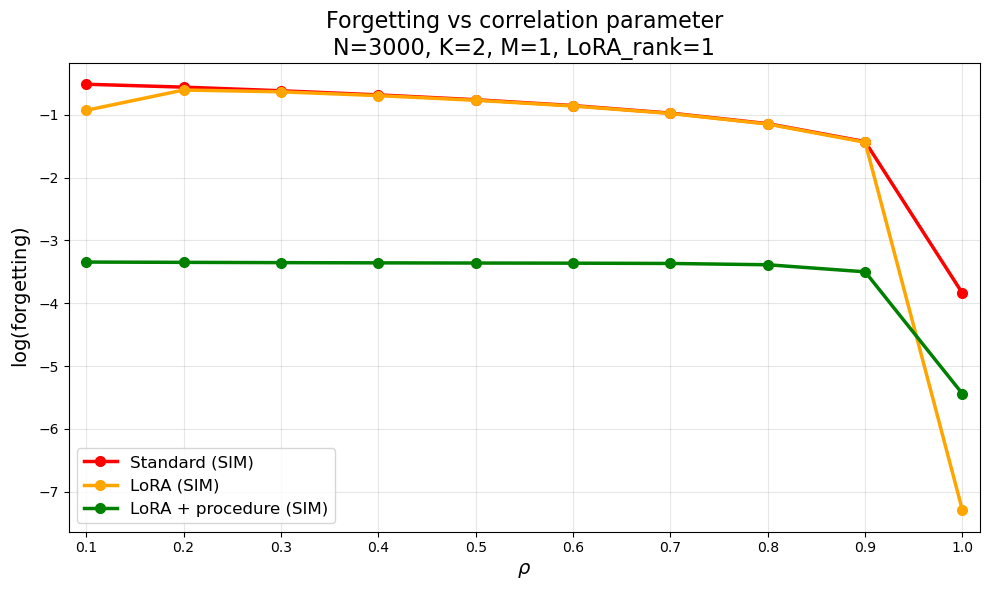

In [247]:
path_to_sim = os.path.join(args.path_to_res_folder,f"sim_K={args.K}_M={args.M}.csv")

path_to_sim_ODEs = os.path.join(args.path_to_res_folder,f"sim_K={args.K}_M={args.M}_ODES.csv")

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "standard": "red",
    "LoRA": "orange",
    "LoRA_A_only": "green",
}

args.method = "standard"
args.A_only = False

forgetting = []
forgetting_ODEs = []

for rho in rhos:

    args.rho = round(float(rho), 1)
    df = load_df_with_constraints(path_to_sim, args)
    #df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

    forgetting.append(df["forgetting"].iloc[-1])
    #forgetting_ODEs.append(df_ODES["forgetting"].iloc[-1])

plot_metric_vs_rho(
    ax,
    rhos,
    forgetting,
    label="Standard",
    color=colors["standard"],
)

args.method = "LoRA"
args.A_only = False

forgetting = []
forgetting_ODEs = []

for rho in rhos:
    args.rho = round(float(rho), 1)

    df = load_df_with_constraints(path_to_sim, args)
    df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

    forgetting.append(df["forgetting"].iloc[-1])
    forgetting_ODEs.append(df_ODES["forgetting"].iloc[-1])

plot_metric_vs_rho(
    ax,
    rhos,
    forgetting,
    label="LoRA",
    color=colors["LoRA"],
)

# ============================================================
# LoRA + additional procedure
# ============================================================

args.method = "LoRA"
args.A_only = True

forgetting = []
forgetting_ODEs = []

rhos = np.arange(0.1,1.01,0.1)
for rho in rhos:
    args.rho = round(float(rho), 1)

    df = load_df_with_constraints(path_to_sim, args)
    df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

    forgetting.append(df["forgetting"].iloc[-1])
    forgetting_ODEs.append(df_ODES["forgetting"].iloc[-1])

plot_metric_vs_rho(
    ax,
    rhos,
    forgetting,
    label="LoRA + procedure",
    color=colors["LoRA_A_only"],
)

# ============================================================
# Final styling
# ============================================================

ax.set_xlabel(r"$\rho$", fontsize=14)

ax.set_ylabel(
    r"$\log(\mathrm{forgetting})$",
    fontsize=14,
)

ax.set_title(
    f"Forgetting vs correlation parameter\n"
    f"N={args.N}, K={args.K}, M={args.M}, "
    f"LoRA_rank={args.L}",
    fontsize=16,
)

ax.grid(True, alpha=0.3)

ax.legend(frameon=True, fontsize=12)

ax.set_xticks(rhos)

plt.tight_layout()

fig.savefig(os.path.join(args.path_to_res_folder, "5-forgetting.pdf"), format="pdf", bbox_inches="tight")
plt.show()

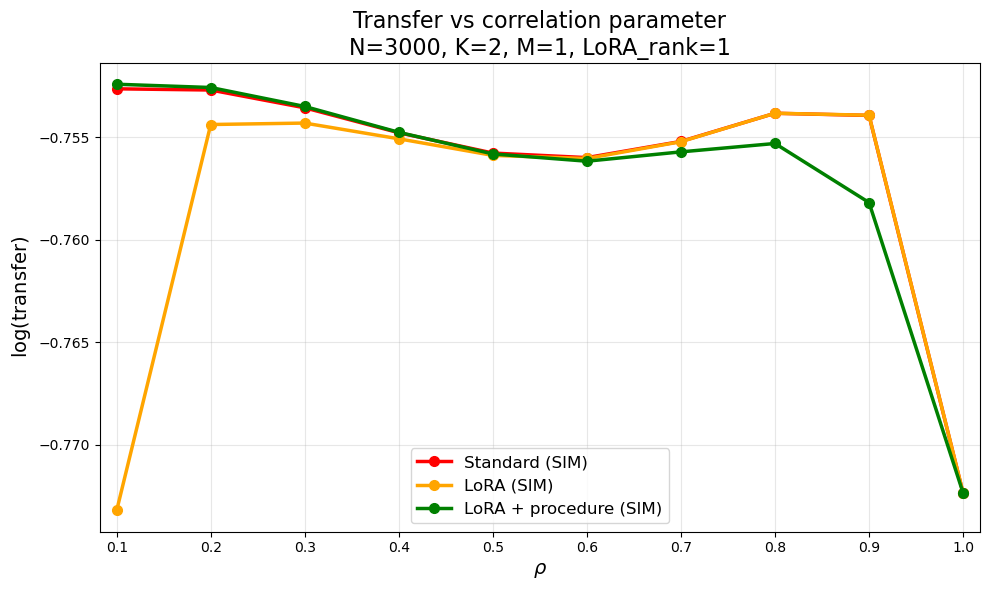

In [249]:
path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"sim_K={args.K}_M={args.M}.csv"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"sim_K={args.K}_M={args.M}_ODES.csv"
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "standard": "red",
    "LoRA": "orange",
    "LoRA_A_only": "green",
}

# ============================================================
# STANDARD
# ============================================================

args.method = "standard"
args.A_only = False

transfer = []
transfer_ODEs = []

for rho in rhos:

    args.rho = round(float(rho), 1)

    df = load_df_with_constraints(path_to_sim, args)

    transfer.append(df["transfer"].iloc[-1])

plot_metric_vs_rho(
    ax,
    rhos,
    transfer,
    label="Standard",
    color=colors["standard"],
    metric_name="transfer",
)

# ============================================================
# LoRA
# ============================================================

args.method = "LoRA"
args.A_only = False

transfer = []
transfer_ODEs = []

for rho in rhos:

    args.rho = round(float(rho), 1)

    df = load_df_with_constraints(path_to_sim, args)
    df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

    transfer.append(df["transfer"].iloc[-1])
    transfer_ODEs.append(df_ODES["transfer"].iloc[-1])

plot_metric_vs_rho(
    ax,
    rhos,
    transfer,
    label="LoRA",
    color=colors["LoRA"],
    metric_name="transfer",
)

# ============================================================
# LoRA + additional procedure
# ============================================================

args.method = "LoRA"
args.A_only = True

transfer = []
transfer_ODEs = []

rhos = np.arange(0.1, 1.01, 0.1)

for rho in rhos:

    args.rho = round(float(rho), 1)

    df = load_df_with_constraints(path_to_sim, args)
    df_ODES = load_df_with_constraints(path_to_sim_ODEs, args)

    transfer.append(df["transfer"].iloc[-1])
    transfer_ODEs.append(df_ODES["transfer"].iloc[-1])

plot_metric_vs_rho(
    ax,
    rhos,
    transfer,
    label="LoRA + procedure",
    color=colors["LoRA_A_only"],
    metric_name="transfer",
)

# ============================================================
# Final styling
# ============================================================

ax.set_xlabel(r"$\rho$", fontsize=14)

ax.set_ylabel(
    r"$\log(\mathrm{transfer})$",
    fontsize=14,
)

ax.set_title(
    f"Transfer vs correlation parameter\n"
    f"N={args.N}, K={args.K}, M={args.M}, "
    f"LoRA_rank={args.L}",
    fontsize=16,
)

ax.grid(True, alpha=0.3)

ax.legend(frameon=True, fontsize=12)

ax.set_xticks(rhos)

plt.tight_layout()
fig.savefig(os.path.join(args.path_to_res_folder, "6-transfer.pdf"), format="pdf", bbox_inches="tight")
plt.show()